# 🚦 London Traffic Prediction — Linear Regression
### Using UK Department for Transport Data — All London Junctions

**Data Source:** roadtraffic.dft.gov.uk  
**Target:** Predict vehicle counts at ALL London junctions  
**Approach:** Progressive feature engineering experiments

---
## Files Needed
- `count_points.csv` → Junction metadata (lat/lon, road names) ✅ Already downloaded
- `raw_counts.csv` → Actual vehicle counts per hour ⚠️ Download from roadtraffic.dft.gov.uk/downloads

## 1. Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Data

In [8]:
# Load count points — junction metadata
count_points = pd.read_csv('../../count_points.csv', low_memory=False)
print('Count Points Shape:', count_points.shape)
print('\nColumns:', count_points.columns.tolist())
count_points.head()

Count Points Shape: (46251, 19)

Columns: ['count_point_id', 'year', 'region_id', 'region_name', 'region_ons_code', 'local_authority_id', 'local_authority_name', 'local_authority_code', 'road_name', 'road_category', 'road_type', 'start_junction_road_name', 'end_junction_road_name', 'easting', 'northing', 'latitude', 'longitude', 'link_length_km', 'link_length_miles']


,count_point_id,year,region_id,region_name,region_ons_code,local_authority_id,local_authority_name,local_authority_code,road_name,road_category,road_type,start_junction_road_name,end_junction_road_name,easting,northing,latitude,longitude,link_length_km,link_length_miles
0,51,2024,1,South West,E12000009,1,Isles of Scilly,E06000053,A3111,PA,Major,"Pierhead, Hugh Town",A3112,90173,10641,49.915503,-6.317558,0.3,0.19
1,52,2024,1,South West,E12000009,1,Isles of Scilly,E06000053,A3112,PA,Major,A3111,A3110,91203,10217,49.912233,-6.302913,2.0,1.24
2,53,2024,1,South West,E12000009,1,Isles of Scilly,E06000053,A3111,PA,Major,A3112,A3110,90782,10687,49.916231,-6.309136,1.2,0.75
3,54,2024,1,South West,E12000009,1,Isles of Scilly,E06000053,A3110,PA,Major,A3111,A3112,91515,10820,49.917802,-6.299062,0.3,0.19
4,55,2024,1,South West,E12000009,1,Isles of Scilly,E06000053,A3110,PA,Major,A3111,A3112,91664,10833,49.917996,-6.297002,4.0,2.49


In [9]:
# Load raw counts — actual vehicle counts
# ⚠️ Download from: roadtraffic.dft.gov.uk/downloads → Raw counts CSV
raw_counts = pd.read_csv('../../dft_traffic_counts_raw_counts.csv', low_memory=False)
print('Raw Counts Shape:', raw_counts.shape)
print('\nColumns:', raw_counts.columns.tolist())
raw_counts.head()

Raw Counts Shape: (5113740, 35)

Columns: ['count_point_id', 'direction_of_travel', 'year', 'count_date', 'hour', 'region_id', 'region_name', 'region_ons_code', 'local_authority_id', 'local_authority_name', 'local_authority_code', 'road_name', 'road_category', 'road_type', 'start_junction_road_name', 'end_junction_road_name', 'easting', 'northing', 'latitude', 'longitude', 'link_length_km', 'link_length_miles', 'pedal_cycles', 'two_wheeled_motor_vehicles', 'cars_and_taxis', 'buses_and_coaches', 'LGVs', 'HGVs_2_rigid_axle', 'HGVs_3_rigid_axle', 'HGVs_4_or_more_rigid_axle', 'HGVs_3_or_4_articulated_axle', 'HGVs_5_articulated_axle', 'HGVs_6_articulated_axle', 'all_HGVs', 'all_motor_vehicles']


,count_point_id,direction_of_travel,year,count_date,hour,region_id,region_name,region_ons_code,local_authority_id,local_authority_name,...,buses_and_coaches,LGVs,HGVs_2_rigid_axle,HGVs_3_rigid_axle,HGVs_4_or_more_rigid_axle,HGVs_3_or_4_articulated_axle,HGVs_5_articulated_axle,HGVs_6_articulated_axle,all_HGVs,all_motor_vehicles
0,51,S,2004,2004-05-21,11,1,South West,E12000009,1,Isles of Scilly,...,2.0,16,2.0,0.0,0.0,0.0,0,0.0,2.0,49.0
1,51,S,2004,2004-05-21,15,1,South West,E12000009,1,Isles of Scilly,...,1.0,13,2.0,0.0,0.0,0.0,0,0.0,2.0,46.0
2,51,S,2004,2004-05-21,13,1,South West,E12000009,1,Isles of Scilly,...,2.0,23,5.0,0.0,0.0,0.0,0,0.0,5.0,51.0
3,51,N,2004,2004-05-21,7,1,South West,E12000009,1,Isles of Scilly,...,1.0,13,0.0,0.0,0.0,0.0,0,0.0,0.0,19.0
4,51,N,2004,2004-05-21,10,1,South West,E12000009,1,Isles of Scilly,...,4.0,4,4.0,0.0,0.0,0.0,0,0.0,4.0,41.0


## 3. Filter ALL London Junctions

In [10]:
# Step 1 — Get ALL London count point IDs
london_cp = count_points[
    count_points['region_name'].str.contains('London', na=False)
]
london_ids = london_cp['count_point_id'].unique().tolist()

print(f'Total London count points: {len(london_ids)}')
print(f'\nLondon boroughs covered ({len(london_cp["local_authority_name"].unique())} boroughs):')
print(london_cp['local_authority_name'].unique())

Total London count points: 3630

London boroughs covered (33 boroughs):
['Barnet' 'Hillingdon' 'Tower Hamlets' 'Islington' 'Southwark' 'Lewisham'
 'Greenwich' 'Bexley' 'Lambeth' 'Wandsworth' 'Westminster'
 'Kensington and Chelsea' 'Hounslow' 'Brent' 'Enfield' 'Hackney'
 'Redbridge' 'Waltham Forest' 'Croydon' 'Camden' 'Hammersmith and Fulham'
 'Ealing' 'Haringey' 'Newham' 'Barking and Dagenham' 'City of London'
 'Richmond upon Thames' 'Bromley' 'Sutton' 'Kingston upon Thames' 'Harrow'
 'Havering' 'Merton']


In [11]:
# Step 2 — Filter raw counts to ALL London junctions
london_traffic = raw_counts[
    raw_counts['count_point_id'].isin(london_ids)
].copy()

print(f'London traffic records: {len(london_traffic):,}')
print(f'Unique junctions:       {london_traffic["count_point_id"].nunique():,}')
print(f'Year range:             {london_traffic["year"].min()} to {london_traffic["year"].max()}')
print(f'\nColumns:')
print(london_traffic.dtypes)

London traffic records: 414,252
Unique junctions:       3,359
Year range:             2000 to 2024

Columns:
count_point_id                    int64
direction_of_travel              object
year                              int64
count_date                       object
hour                              int64
region_id                         int64
region_name                      object
region_ons_code                  object
local_authority_id                int64
local_authority_name             object
local_authority_code             object
road_name                        object
road_category                    object
road_type                        object
start_junction_road_name         object
end_junction_road_name           object
easting                           int64
northing                          int64
latitude                        float64
longitude                       float64
link_length_km                  float64
link_length_miles               float64
pedal_cycle

In [12]:
# Step 3 — Rename to standard format
df = london_traffic.rename(columns={
    'count_point_id':    'Junction',
    'all_motor_vehicles': 'Vehicles'
}).copy()

# Drop rows with missing vehicle counts
df = df.dropna(subset=['Vehicles'])

print(f'Final dataset shape: {df.shape}')
print(f'\nVehicle count statistics:')
print(df['Vehicles'].describe())

Final dataset shape: (414251, 35)

Vehicle count statistics:
count    414251.000000
mean        738.456264
std         902.942942
min           0.000000
25%         133.000000
50%         470.000000
75%         897.000000
max       10905.000000
Name: Vehicles, dtype: float64


## 4. Create DateTime Column

In [13]:
# Check available time columns
time_cols = [c for c in df.columns if any(t in c.lower()
             for t in ['year', 'month', 'day', 'hour', 'date', 'time'])]
print('Time columns found:', time_cols)
print('\nSample values:')
print(df[time_cols].head())

Time columns found: ['year', 'count_date', 'hour']

Sample values:
       year  count_date  hour
30192  2000  2000-03-27     7
30193  2000  2000-03-27    14
30194  2000  2000-03-27    17
30195  2000  2000-03-27     9
30196  2000  2000-03-27    16


In [ ]:
# Build DateTime
df['DateTime'] = pd.to_datetime(df['count_date'])

df['hour']    = df['DateTime'].dt.hour
df['day']     = df['DateTime'].dt.day
df['month']   = df['DateTime'].dt.month
df['weekday'] = df['DateTime'].dt.weekday

print('DateTime created!')
print(f'Date range: {df["DateTime"].min()} → {df["DateTime"].max()}')
df[['Junction', 'DateTime', 'hour', 'day', 'month', 'weekday', 'Vehicles']].head(10)

DateTime created!
Date range: 2000-03-17 00:00:00 → 2024-11-06 00:00:00


,Junction,DateTime,hour,day,month,weekday,Vehicles
30192,6000,2000-03-27,0,27,3,0,2311.0
30193,6000,2000-03-27,0,27,3,0,1559.0
30194,6000,2000-03-27,0,27,3,0,710.0
30195,6000,2000-03-27,0,27,3,0,2270.0
30196,6000,2000-03-27,0,27,3,0,936.0
30197,6000,2000-03-27,0,27,3,0,737.0
30198,6000,2000-03-27,0,27,3,0,528.0
30199,6000,2000-03-27,0,27,3,0,945.0
30200,6000,2000-03-27,0,27,3,0,1633.0
30201,6000,2000-03-27,0,27,3,0,1469.0


## 5. EDA — Exploratory Data Analysis

In [15]:
print(f'Total records:      {len(df):,}')
print(f'Total junctions:    {df["Junction"].nunique():,}')
print(f'Year range:         {df["DateTime"].dt.year.min()} → {df["DateTime"].dt.year.max()}')
print(f'Avg vehicles/hr:    {df["Vehicles"].mean():.0f}')
print(f'Max vehicles/hr:    {df["Vehicles"].max():.0f}')

Total records:      414,251
Total junctions:    3,359
Year range:         2000 → 2024
Avg vehicles/hr:    738
Max vehicles/hr:    10905


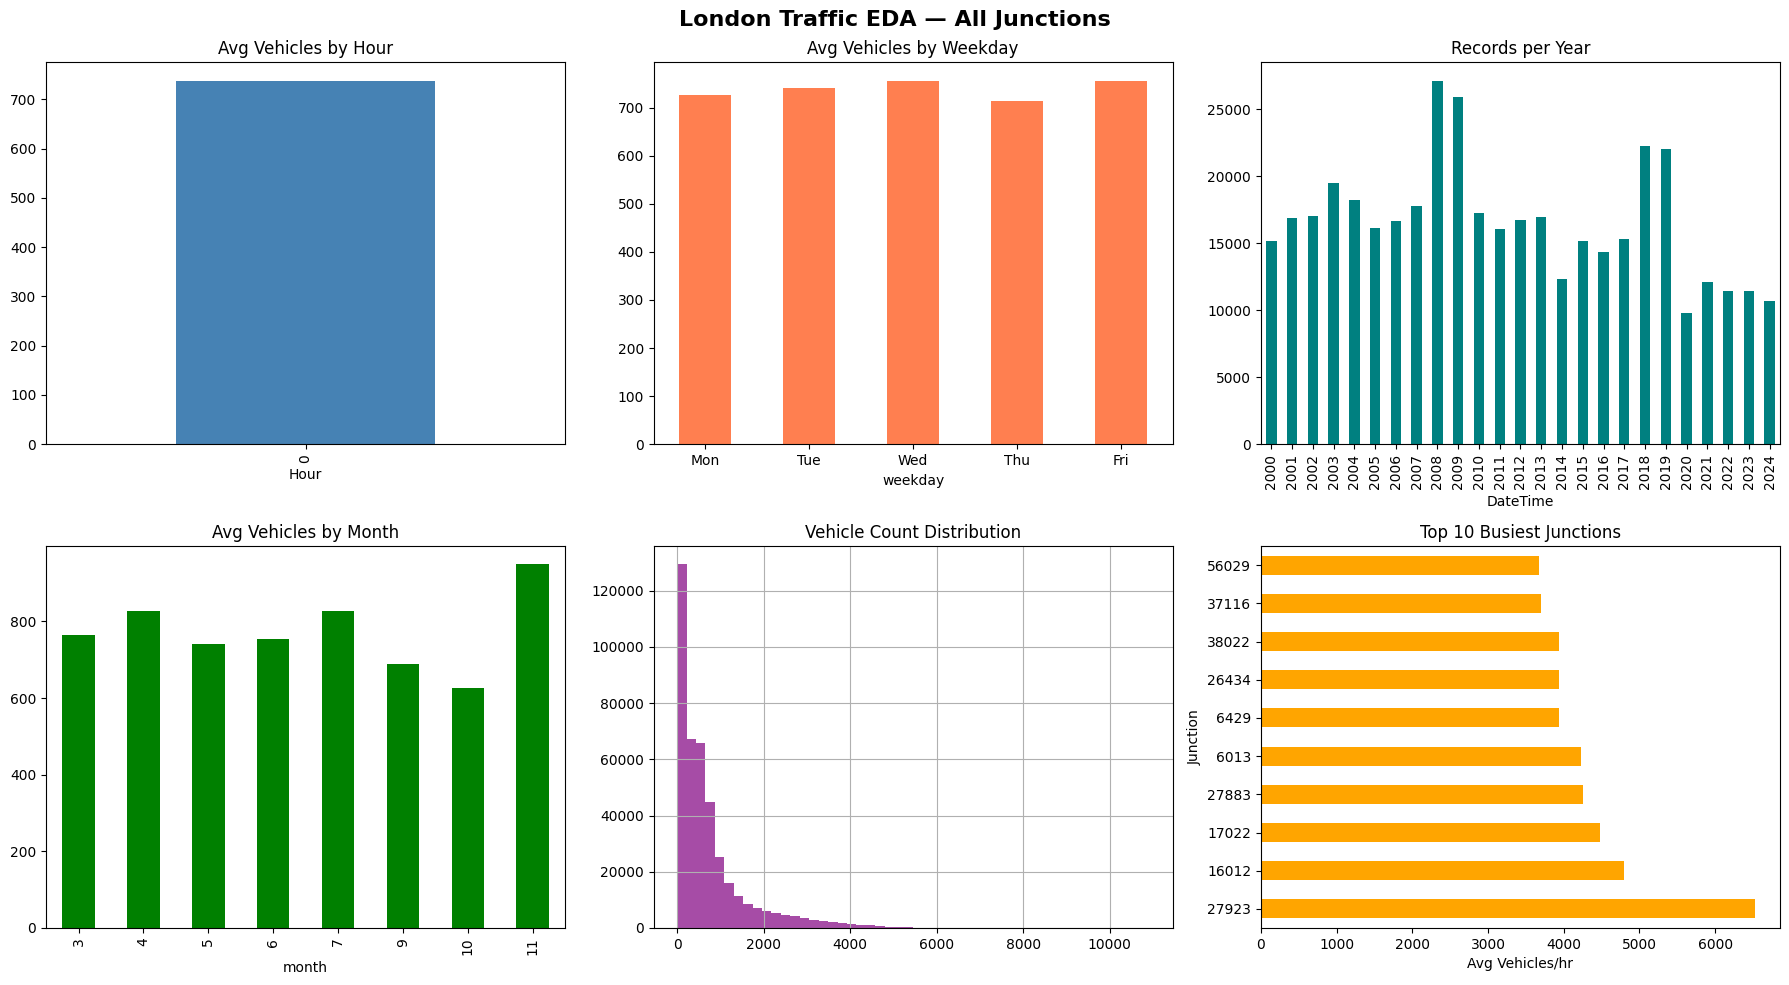

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('London Traffic EDA — All Junctions', fontsize=16, fontweight='bold')

# Traffic by hour
df.groupby('hour')['Vehicles'].mean().plot(
    kind='bar', ax=axes[0,0], color='steelblue'
)
axes[0,0].set_title('Avg Vehicles by Hour')
axes[0,0].set_xlabel('Hour')

# Traffic by weekday ← Fixed version
weekday_avg = df.groupby('weekday')['Vehicles'].mean()
weekday_avg.plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Avg Vehicles by Weekday')
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
# Only set labels for weekdays that actually exist in data
axes[0,1].set_xticklabels(
    [days[i] for i in weekday_avg.index], rotation=0
)

# Traffic by month
df.groupby('month')['Vehicles'].mean().plot(
    kind='bar', ax=axes[1,0], color='green'
)
axes[1,0].set_title('Avg Vehicles by Month')

# Traffic distribution
df['Vehicles'].hist(bins=50, ax=axes[1,1], color='purple', alpha=0.7)
axes[1,1].set_title('Vehicle Count Distribution')

# Top 10 busiest junctions
top10 = df.groupby('Junction')['Vehicles'].mean().nlargest(10)
top10.plot(kind='barh', ax=axes[1,2], color='orange')
axes[1,2].set_title('Top 10 Busiest Junctions')
axes[1,2].set_xlabel('Avg Vehicles/hr')

# Records per year
df.groupby(df['DateTime'].dt.year)['Vehicles'].count().plot(
    kind='bar', ax=axes[0,2], color='teal'
)
axes[0,2].set_title('Records per Year')

plt.tight_layout()
plt.show()

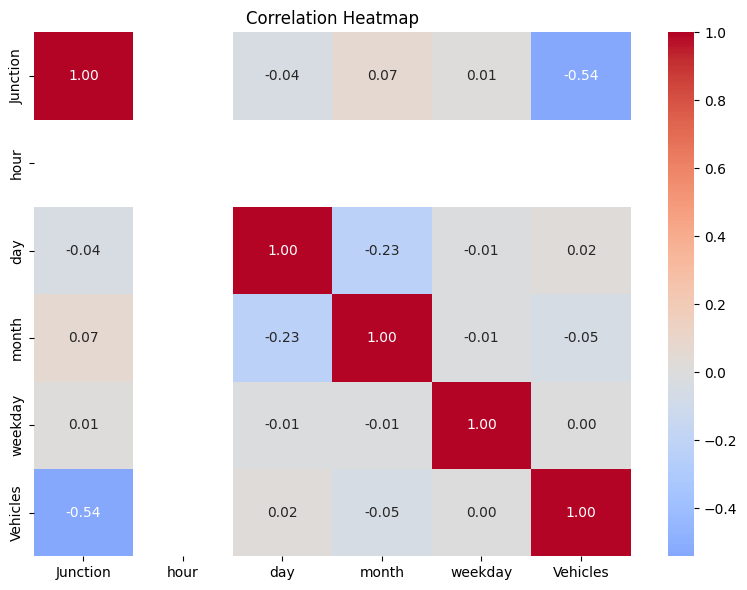

In [17]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr_cols = ['Junction', 'hour', 'day', 'month', 'weekday', 'Vehicles']
sns.heatmap(
    df[corr_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 6. Helper — Evaluate Model

In [18]:
results = []

def evaluate(name, Y_test, y_pred, Y_train, y_pred_train):
    test_mae  = mean_absolute_error(Y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
    test_r2   = r2_score(Y_test, y_pred)
    train_r2  = r2_score(Y_train, y_pred_train)
    gap       = abs(train_r2 - test_r2)

    print(f'\n{"-"*55}')
    print(f'  Model: {name}')
    print(f'{"-"*55}')
    print(f'  For Test .....')
    print(f'  MAE:  {test_mae:.4f}')
    print(f'  RMSE: {test_rmse:.4f}')
    print(f'  R2:   {test_r2:.4f}')
    print(f'  For Train .....')
    print(f'  MAE:  {mean_absolute_error(Y_train, y_pred_train):.4f}')
    print(f'  RMSE: {np.sqrt(mean_squared_error(Y_train, y_pred_train)):.4f}')
    print(f'  R2:   {train_r2:.4f}')
    print(f'  Gap:  {gap:.4f}')

    results.append({
        'Model':     name,
        'Test MAE':  round(test_mae, 4),
        'Test RMSE': round(test_rmse, 4),
        'Test R²':   round(test_r2, 4),
        'Train R²':  round(train_r2, 4),
        'Gap':       round(gap, 4)
    })
    return test_r2

print('Evaluate function ready!')

Evaluate function ready!


## 7. Baseline — Basic Time Features

In [19]:
X_base = df[['Junction', 'hour', 'day', 'month', 'weekday']]
Y_base = df['Vehicles']

# shuffle=True — safe since no lag features
X_base_train, X_base_test, Y_base_train, Y_base_test = train_test_split(
    X_base, Y_base, test_size=0.2, random_state=42, shuffle=True
)

scaler_base = StandardScaler()
X_base_train_s = scaler_base.fit_transform(X_base_train)
X_base_test_s  = scaler_base.transform(X_base_test)

base_model = LinearRegression()
base_model.fit(X_base_train_s, Y_base_train)

evaluate(
    'LR Baseline',
    Y_base_test, base_model.predict(X_base_test_s),
    Y_base_train, base_model.predict(X_base_train_s)
)


-------------------------------------------------------
  Model: LR Baseline
-------------------------------------------------------
  For Test .....
  MAE:  485.8162
  RMSE: 766.0969
  R2:   0.2896
  For Train .....
  MAE:  480.5436
  RMSE: 757.7006
  R2:   0.2935
  Gap:  0.0038


0.2896256054014712

## 8. exp1 — Rush Hour & Weekend Flags

In [20]:
df_exp1 = df.copy()
df_exp1['is_rush_hour'] = df_exp1['hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)
df_exp1['is_weekend']   = (df_exp1['weekday'] >= 5).astype(int)

X1 = df_exp1[['Junction', 'hour', 'day', 'month', 'weekday',
              'is_rush_hour', 'is_weekend']]
Y1 = df_exp1['Vehicles']

X1_train, X1_test, Y1_train, Y1_test = train_test_split(
    X1, Y1, test_size=0.2, random_state=42, shuffle=True
)

scaler1 = StandardScaler()
X1_train_s = scaler1.fit_transform(X1_train)
X1_test_s  = scaler1.transform(X1_test)

exp1_model = LinearRegression()
exp1_model.fit(X1_train_s, Y1_train)

evaluate(
    'LR exp1 — Rush Hour + Weekend',
    Y1_test, exp1_model.predict(X1_test_s),
    Y1_train, exp1_model.predict(X1_train_s)
)


-------------------------------------------------------
  Model: LR exp1 — Rush Hour + Weekend
-------------------------------------------------------
  For Test .....
  MAE:  485.8162
  RMSE: 766.0969
  R2:   0.2896
  For Train .....
  MAE:  480.5436
  RMSE: 757.7006
  R2:   0.2935
  Gap:  0.0038


0.2896256054014712

## 9. exp2 — Lag Features + Time-Based Split
### ⚠️ Key change: sort by DateTime only — ensures ALL junctions in test set

In [21]:
df_exp2 = df.copy()

# Sort by DateTime only — critical for fair split across all junctions
df_exp2 = df_exp2.sort_values(by=['DateTime'])

# Lag features — grouped by junction so junctions don't bleed into each other
df_exp2['lag_1']  = df_exp2.groupby('Junction')['Vehicles'].shift(1)
df_exp2['lag_2']  = df_exp2.groupby('Junction')['Vehicles'].shift(2)
df_exp2['lag_24'] = df_exp2.groupby('Junction')['Vehicles'].shift(24)

df_exp2['is_rush_hour'] = df_exp2['hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)
df_exp2['is_weekend']   = (df_exp2['weekday'] >= 5).astype(int)

df_exp2 = df_exp2.dropna()
print(f'Records after dropna: {len(df_exp2):,}')
print(f'Junctions retained:   {df_exp2["Junction"].nunique():,}')

X2 = df_exp2[['Junction', 'hour', 'day', 'month', 'weekday',
              'lag_1', 'lag_2', 'lag_24',
              'is_rush_hour', 'is_weekend']]
Y2 = df_exp2['Vehicles']

# shuffle=False — time-based split
X2_train, X2_test, Y2_train, Y2_test = train_test_split(
    X2, Y2, test_size=0.2, random_state=42, shuffle=False
)

scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s  = scaler2.transform(X2_test)

exp2_model = LinearRegression()
exp2_model.fit(X2_train_s, Y2_train)

evaluate(
    'LR exp2 — Lag Features',
    Y2_test, exp2_model.predict(X2_test_s),
    Y2_train, exp2_model.predict(X2_train_s)
)

Records after dropna: 190,583
Junctions retained:   1,620

-------------------------------------------------------
  Model: LR exp2 — Lag Features
-------------------------------------------------------
  For Test .....
  MAE:  207.5094
  RMSE: 332.1590
  R2:   0.9078
  For Train .....
  MAE:  249.9683
  RMSE: 412.6966
  R2:   0.8392
  Gap:  0.0686


0.9077784069080107

## 10. exp3 — Rolling Mean Features

In [22]:
df_exp3 = df.copy()
df_exp3 = df_exp3.sort_values(by=['DateTime'])

# Lag features
df_exp3['lag_1']  = df_exp3.groupby('Junction')['Vehicles'].shift(1)
df_exp3['lag_2']  = df_exp3.groupby('Junction')['Vehicles'].shift(2)
df_exp3['lag_24'] = df_exp3.groupby('Junction')['Vehicles'].shift(24)

# Rolling means — captures recent trend, computed per junction
df_exp3['rolling_mean_3'] = df_exp3.groupby('Junction')['Vehicles'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
df_exp3['rolling_mean_24'] = df_exp3.groupby('Junction')['Vehicles'].transform(
    lambda x: x.shift(1).rolling(24).mean()
)

df_exp3['is_rush_hour'] = df_exp3['hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)
df_exp3['is_weekend']   = (df_exp3['weekday'] >= 5).astype(int)

df_exp3 = df_exp3.dropna()
print(f'Records after dropna: {len(df_exp3):,}')

X3 = df_exp3[['Junction', 'hour', 'day', 'month', 'weekday',
              'lag_1', 'lag_2', 'lag_24',
              'rolling_mean_3', 'rolling_mean_24',
              'is_rush_hour', 'is_weekend']]
Y3 = df_exp3['Vehicles']

X3_train, X3_test, Y3_train, Y3_test = train_test_split(
    X3, Y3, test_size=0.2, random_state=42, shuffle=False
)

scaler3 = StandardScaler()
X3_train_s = scaler3.fit_transform(X3_train)
X3_test_s  = scaler3.transform(X3_test)

exp3_model = LinearRegression()
exp3_model.fit(X3_train_s, Y3_train)

evaluate(
    'LR exp3 — Rolling Means',
    Y3_test, exp3_model.predict(X3_test_s),
    Y3_train, exp3_model.predict(X3_train_s)
)

Records after dropna: 190,583

-------------------------------------------------------
  Model: LR exp3 — Rolling Means
-------------------------------------------------------
  For Test .....
  MAE:  197.1648
  RMSE: 313.5378
  R2:   0.9178
  For Train .....
  MAE:  229.4461
  RMSE: 375.1859
  R2:   0.8671
  Gap:  0.0507


0.9178286821815932

## 11. exp4 — UK Holiday Feature

In [23]:
# pip install holidays
import holidays as hd

df_exp4 = df_exp3.copy()

# UK public holidays — covers all years in dataset
uk_holidays = hd.UK(years=range(
    df_exp4['DateTime'].dt.year.min(),
    df_exp4['DateTime'].dt.year.max() + 1
))

df_exp4['is_holiday'] = df_exp4['DateTime'].dt.date.apply(
    lambda x: 1 if x in uk_holidays else 0
)

print(f'Holiday hours flagged: {df_exp4["is_holiday"].sum():,}')
print(f'Total hours:           {len(df_exp4):,}')
print(f'Holiday percentage:    {df_exp4["is_holiday"].mean()*100:.2f}%')

X4 = df_exp4[['Junction', 'hour', 'day', 'month', 'weekday',
              'lag_1', 'lag_2', 'lag_24',
              'rolling_mean_3', 'rolling_mean_24',
              'is_rush_hour', 'is_weekend', 'is_holiday']]
Y4 = df_exp4['Vehicles']

X4_train, X4_test, Y4_train, Y4_test = train_test_split(
    X4, Y4, test_size=0.2, random_state=42, shuffle=False
)

scaler4 = StandardScaler()
X4_train_s = scaler4.fit_transform(X4_train)
X4_test_s  = scaler4.transform(X4_test)

exp4_model = LinearRegression()
exp4_model.fit(X4_train_s, Y4_train)

evaluate(
    'LR exp4 — UK Holidays',
    Y4_test, exp4_model.predict(X4_test_s),
    Y4_train, exp4_model.predict(X4_train_s)
)

Holiday hours flagged: 0
Total hours:           190,583
Holiday percentage:    0.00%

-------------------------------------------------------
  Model: LR exp4 — UK Holidays
-------------------------------------------------------
  For Test .....
  MAE:  197.1648
  RMSE: 313.5378
  R2:   0.9178
  For Train .....
  MAE:  229.4461
  RMSE: 375.1859
  R2:   0.8671
  Gap:  0.0507


0.9178286821815932

## 12. exp5 — Cyclic Time Encoding

In [24]:
df_exp5 = df_exp4.copy()

# Cyclic encoding — hour 23 and hour 0 are close, not far
df_exp5['hour_sin']    = np.sin(2 * np.pi * df_exp5['hour'] / 24)
df_exp5['hour_cos']    = np.cos(2 * np.pi * df_exp5['hour'] / 24)
df_exp5['month_sin']   = np.sin(2 * np.pi * df_exp5['month'] / 12)
df_exp5['month_cos']   = np.cos(2 * np.pi * df_exp5['month'] / 12)
df_exp5['weekday_sin'] = np.sin(2 * np.pi * df_exp5['weekday'] / 7)
df_exp5['weekday_cos'] = np.cos(2 * np.pi * df_exp5['weekday'] / 7)

# Use cyclic features instead of raw hour/month/weekday
X5 = df_exp5[['Junction',
              'hour_sin', 'hour_cos',
              'month_sin', 'month_cos',
              'weekday_sin', 'weekday_cos',
              'lag_1', 'lag_2', 'lag_24',
              'rolling_mean_3', 'rolling_mean_24',
              'is_rush_hour', 'is_weekend', 'is_holiday']]
Y5 = df_exp5['Vehicles']

X5_train, X5_test, Y5_train, Y5_test = train_test_split(
    X5, Y5, test_size=0.2, random_state=42, shuffle=False
)

scaler5 = StandardScaler()
X5_train_s = scaler5.fit_transform(X5_train)
X5_test_s  = scaler5.transform(X5_test)

exp5_model = LinearRegression()
exp5_model.fit(X5_train_s, Y5_train)

evaluate(
    'LR exp5 — Cyclic Features',
    Y5_test, exp5_model.predict(X5_test_s),
    Y5_train, exp5_model.predict(X5_train_s)
)


-------------------------------------------------------
  Model: LR exp5 — Cyclic Features
-------------------------------------------------------
  For Test .....
  MAE:  197.2090
  RMSE: 313.5322
  R2:   0.9178
  For Train .....
  MAE:  229.4550
  RMSE: 375.1773
  R2:   0.8671
  Gap:  0.0507


0.9178315851775894

## 13. Feature Importance

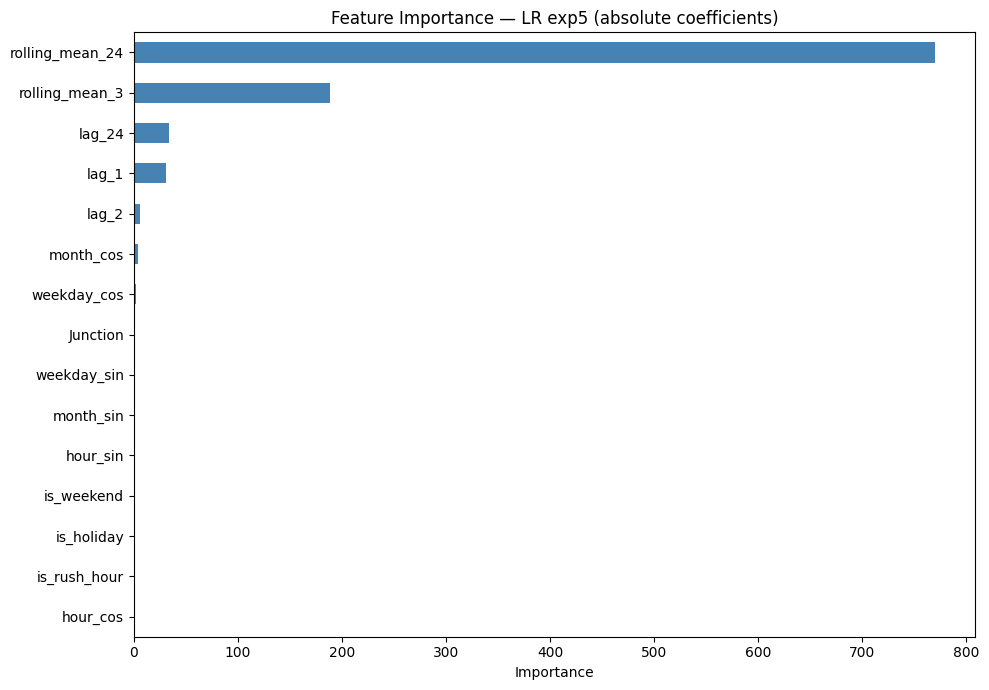


Top 5 most important features:
rolling_mean_24    770.262316
rolling_mean_3     188.431188
lag_24              34.222091
lag_1               30.648476
lag_2                6.022574
dtype: float64


In [25]:
feature_names = X5.columns.tolist()

lr_importance = pd.Series(
    np.abs(exp5_model.coef_),
    index=feature_names
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
lr_importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — LR exp5 (absolute coefficients)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(lr_importance.nlargest(5))

## 14. Final Comparison — All Models

In [26]:
results_df = pd.DataFrame(results)
print('='*70)
print('FINAL MODEL COMPARISON — ALL LONDON JUNCTIONS')
print('='*70)
print(results_df.to_string(index=False))

FINAL MODEL COMPARISON — ALL LONDON JUNCTIONS
                        Model  Test MAE  Test RMSE  Test R²  Train R²    Gap
                  LR Baseline  485.8162   766.0969   0.2896    0.2935 0.0038
LR exp1 — Rush Hour + Weekend  485.8162   766.0969   0.2896    0.2935 0.0038
       LR exp2 — Lag Features  207.5094   332.1590   0.9078    0.8392 0.0686
      LR exp3 — Rolling Means  197.1648   313.5378   0.9178    0.8671 0.0507
        LR exp4 — UK Holidays  197.1648   313.5378   0.9178    0.8671 0.0507
    LR exp5 — Cyclic Features  197.2090   313.5322   0.9178    0.8671 0.0507


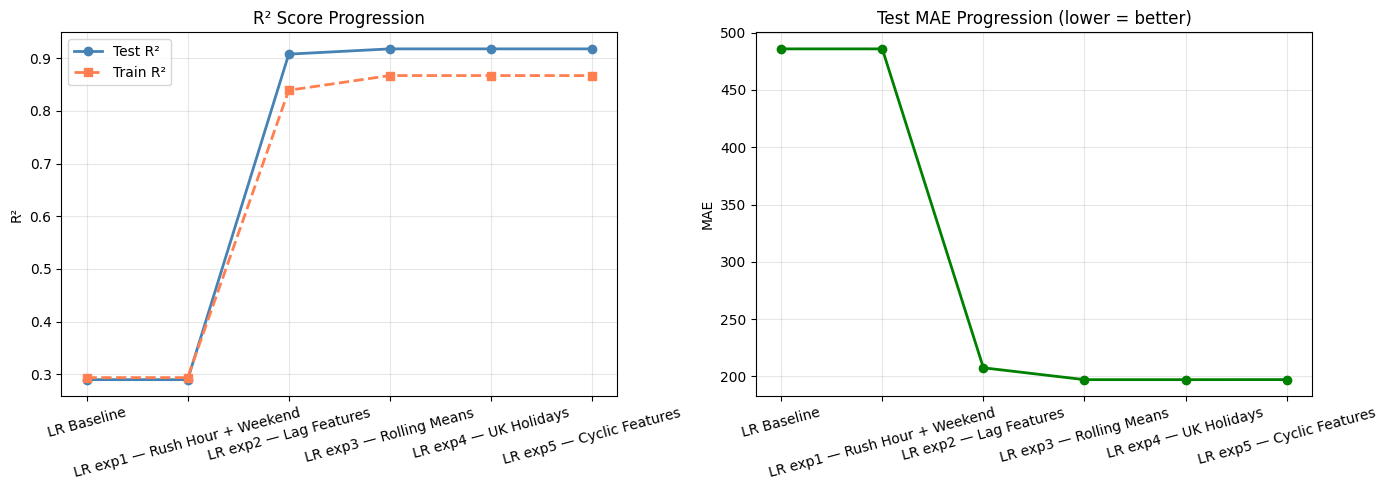

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² progression
axes[0].plot(results_df['Model'], results_df['Test R²'],
             marker='o', color='steelblue', label='Test R²', linewidth=2)
axes[0].plot(results_df['Model'], results_df['Train R²'],
             marker='s', color='coral', label='Train R²', linewidth=2, linestyle='--')
axes[0].set_title('R² Score Progression')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE progression
axes[1].plot(results_df['Model'], results_df['Test MAE'],
             marker='o', color='green', linewidth=2)
axes[1].set_title('Test MAE Progression (lower = better)')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()